# SafeLIBERO training vs. test initial states

This notebook renders newly generated training initial states beside the fixed SafeLIBERO evaluation states. It reads the evaluation files without modifying them.

In [10]:
from __future__ import annotations

import os
import sys
from pathlib import Path

# Headless rendering must be selected before importing MuJoCo / LIBERO.
os.environ.setdefault("MUJOCO_GL", "osmesa")
os.environ.setdefault("PYOPENGL_PLATFORM", "osmesa")

ROOT = Path.cwd().resolve()
if not (ROOT / "safelibero").is_dir():
    raise RuntimeError("Run this notebook from /home/lythk/safe-flow-matching")
sys.path.insert(0, str(ROOT / "safelibero"))

import matplotlib.pyplot as plt
import numpy as np
# import torch
from libero.libero import benchmark, get_libero_path
from libero.libero.envs import OffScreenRenderEnv

# Change these values to inspect another task.
SUITE = "safelibero_spatial"
SAFETY_LEVEL = "I"
TASK_ID = 0
COUNT = 6
HEIGHT = 128
WIDTH = 128
OUTPUT = ROOT / "safelibero_train_test_initials.png"


ImportError: Numba needs NumPy 2.4 or less. Got NumPy 2.5.

In [ ]:
suites = benchmark.get_benchmark_dict()
if SUITE not in suites:
    raise ValueError(f"Unknown suite {SUITE!r}; choose one of {sorted(suites)}")

task_suite = suites[SUITE](safety_level=SAFETY_LEVEL)
if not 0 <= TASK_ID < task_suite.get_num_tasks():
    raise ValueError(f"TASK_ID must be between 0 and {task_suite.get_num_tasks() - 1}")

task = task_suite.get_task(TASK_ID)
bddl_path = Path(get_libero_path("bddl_files")) / task.problem_folder / task.bddl_file
test_states = np.asarray(task_suite.get_task_init_states(TASK_ID))
training_name = Path(task.init_states_file).name.replace(
    ".pruned_init", f"_level_{SAFETY_LEVEL}.pruned_init"
)
training_path = (
    ROOT / "safelibero/libero/libero/init_file_two_obstacles_testing"
    / task.problem_folder / training_name
)
if not bddl_path.is_file():
    raise FileNotFoundError(f"BDDL file not found: {bddl_path}")
if not training_path.is_file():
    raise FileNotFoundError(
        f"Training initial states not found: {training_path}\n"
        "Generate them with training_dataset_generator/generate_native_safelibero.py"
    )
training_states = np.asarray(torch.load(training_path, map_location="cpu"))
if training_states.ndim != 2 or test_states.ndim != 2:
    raise ValueError("Expected both initial-state arrays to be two-dimensional")
if training_states.shape[1] != test_states.shape[1]:
    raise ValueError(
        f"State dimensions differ: training={training_states.shape}, test={test_states.shape}"
    )
count = min(COUNT, len(training_states), len(test_states))
if count < 1:
    raise ValueError("No initial states are available to render")
print(f"Task: {task.language}")
print(f"BDDL: {bddl_path}")
print(f"Training states: {training_path} {training_states.shape}")
print(f"Fixed test states (read-only): {test_states.shape}")


[info] using task orders [0, 1, 2, 3]
[Warning]: datasets path /home/lythk/safe-flow-matching/safelibero/libero/datasets does not exist!
[Warning]: datasets path /home/lythk/safe-flow-matching/safelibero/libero/datasets does not exist!
Task: pick up the black bowl between the plate and the ramekin and place it on the plate
BDDL: /home/lythk/safe-flow-matching/safelibero/libero/libero/bddl_files/safelibero_spatial/pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate.bddl
Training states: /home/lythk/safe-flow-matching/safelibero/libero/libero/init_files_training/safelibero_spatial/pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate_level_I.pruned_init (80, 183)
Fixed test states (read-only): (50, 183)


Saved comparison to /home/lythk/safe-flow-matching/safelibero_train_test_initials.png


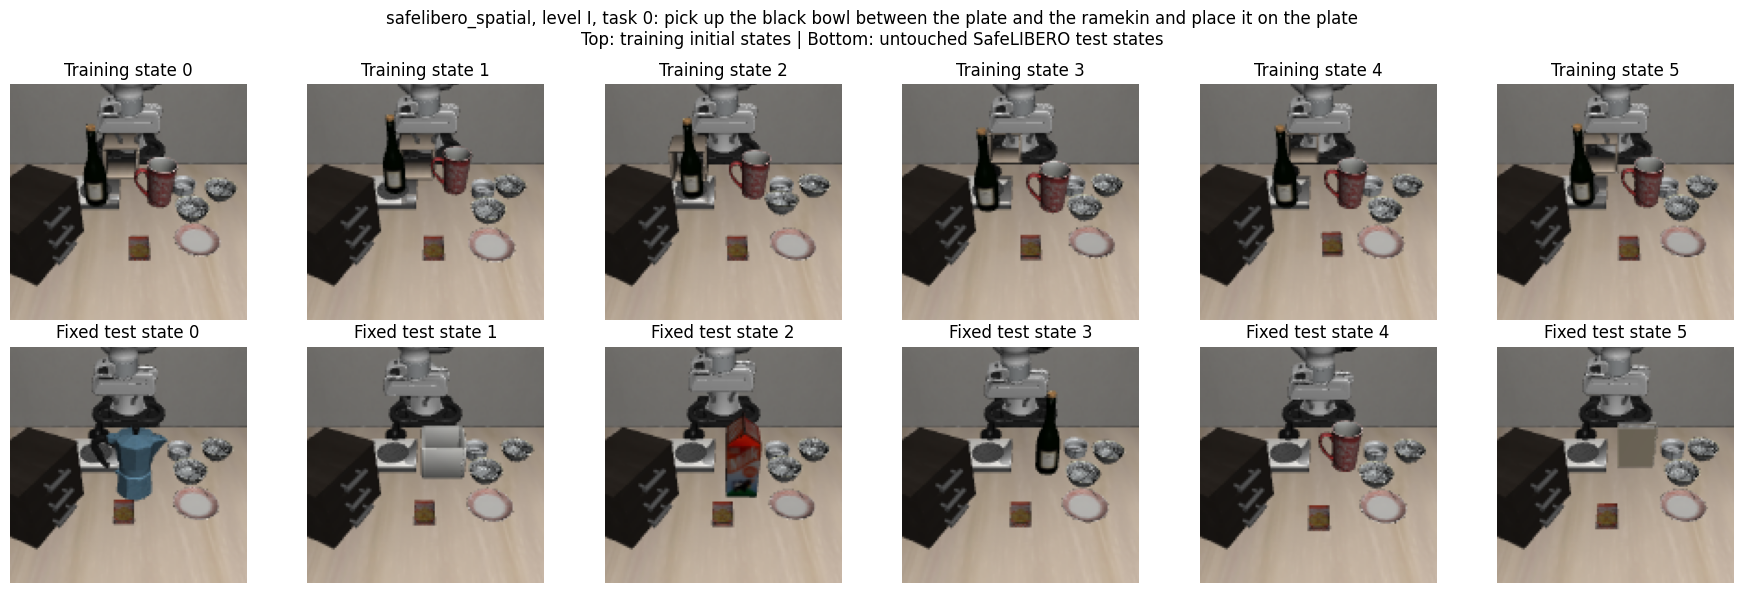

In [ ]:
def render_states(states: np.ndarray, count: int) -> list[np.ndarray]:
    env = OffScreenRenderEnv(
        bddl_file_name=str(bddl_path),
        camera_heights=HEIGHT,
        camera_widths=WIDTH,
    )
    images = []
    try:
        env.seed(0)
        env.reset()
        for state in states[:count]:
            obs = env.set_init_state(state)
            # One neutral step refreshes every observation after set_init_state.
            obs, _, _, _ = env.step(np.zeros(7, dtype=np.float32))
            images.append(np.asarray(obs["agentview_image"])[::-1].copy())
    finally:
        env.close()
    return images

training_images = render_states(training_states, count)
test_images = render_states(test_states, count)

fig, axes = plt.subplots(2, count, figsize=(3 * count, 6), squeeze=False)
for column in range(count):
    axes[0, column].imshow(training_images[column])
    axes[0, column].set_title(f"Training state {column}")
    axes[1, column].imshow(test_images[column])
    axes[1, column].set_title(f"Fixed test state {column}")
    axes[0, column].axis("off")
    axes[1, column].axis("off")
fig.suptitle(
    f"{SUITE}, level {SAFETY_LEVEL}, task {TASK_ID}: {task.language}\n"
    "Top: training initial states | Bottom: untouched SafeLIBERO test states",
    fontsize=12,
)
fig.tight_layout()
fig.savefig(OUTPUT, dpi=180, bbox_inches="tight")
print(f"Saved comparison to {OUTPUT}")
plt.show()


In [ ]:
#!/usr/bin/env python3
"""Render fixed LIBERO evaluation states and first frames of training demos.

Run from an environment where the official LIBERO repository and datasets are
installed. Example:

    MUJOCO_GL=egl python render_libero_train_test_initials.py \
        --suite libero_10 --task-id 9 --count 6 \
        --output libero_init_comparison.png
"""

from __future__ import annotations

import argparse
import os
import re
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

from libero.libero import benchmark, get_libero_path
from libero.libero.envs import OffScreenRenderEnv


def natural_demo_key(key: str) -> int:
    match = re.fullmatch(r"demo_(\d+)", key)
    if match is None:
        raise ValueError(f"Unexpected demonstration key: {key!r}")
    return int(match.group(1))


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--suite", default="libero_10")
    parser.add_argument("--task-id", type=int, default=9)
    parser.add_argument("--count", type=int, default=6)
    parser.add_argument("--height", type=int, default=128)
    parser.add_argument("--width", type=int, default=128)
    parser.add_argument("--output", default="libero_init_comparison.png")
    args = parser.parse_args()

    suites = benchmark.get_benchmark_dict()
    if args.suite not in suites:
        raise ValueError(
            f"Unknown suite {args.suite!r}. Available suites: {sorted(suites)}"
        )

    task_suite = suites[args.suite]()
    if not 0 <= args.task_id < task_suite.get_num_tasks():
        raise ValueError(
            f"task-id must be in [0, {task_suite.get_num_tasks() - 1}]"
        )

    task = task_suite.get_task(args.task_id)
    bddl_path = os.path.join(
        get_libero_path("bddl_files"), task.problem_folder, task.bddl_file
    )
    demo_path = os.path.join(
        get_libero_path("datasets"), task_suite.get_task_demonstration(args.task_id)
    )

    if not os.path.exists(bddl_path):
        raise FileNotFoundError(f"BDDL file not found: {bddl_path}")
    if not os.path.exists(demo_path):
        raise FileNotFoundError(
            f"Demonstration file not found: {demo_path}\n"
            "Download the official LIBERO datasets first."
        )

    init_states = task_suite.get_task_init_states(args.task_id)
    count = min(args.count, len(init_states))

    env = OffScreenRenderEnv(
        bddl_file_name=bddl_path,
        camera_heights=args.height,
        camera_widths=args.width,
    )
    env.seed(0)

    eval_images: list[np.ndarray] = []
    try:
        env.reset()
        for index in range(count):
            env.set_init_state(init_states[index])
            obs = None
            for _ in range(5):
                obs, _, _, _ = env.step(np.zeros(7, dtype=np.float32))
            assert obs is not None
            # LIBERO's notebook flips the vertical image axis for display.
            eval_images.append(obs["agentview_image"][::-1].copy())
    finally:
        env.close()

    with h5py.File(demo_path, "r") as h5_file:
        demo_keys = sorted(h5_file["data"].keys(), key=natural_demo_key)
        selected_keys = demo_keys[:count]
        train_images = [
            h5_file[f"data/{key}/obs/agentview_rgb"][0][::-1].copy()
            for key in selected_keys
        ]

    fig, axes = plt.subplots(2, count, figsize=(3 * count, 6), squeeze=False)
    for column in range(count):
        axes[0, column].imshow(train_images[column])
        axes[0, column].set_title(f"Training demo {natural_demo_key(selected_keys[column])}")
        axes[0, column].axis("off")

        axes[1, column].imshow(eval_images[column])
        axes[1, column].set_title(f"Fixed eval state {column}")
        axes[1, column].axis("off")

    fig.suptitle(
        f"{args.suite}, task {args.task_id}: {task.language}\n"
        "Top: first frame of expert demonstrations | Bottom: fixed evaluation states",
        fontsize=12,
    )
    fig.tight_layout()
    output = Path(args.output).expanduser().resolve()
    fig.savefig(output, dpi=180, bbox_inches="tight")
    print(f"Saved comparison to {output}")
    print(f"Task: {task.language}")
    print(f"Fixed evaluation-state tensor shape: {tuple(init_states.shape)}")
    print(f"Demonstration file: {demo_path}")


if __name__ == "__main__":
    main()

ModuleNotFoundError: No module named 'h5py'